## Notebook 05b — Rolling Granger Causality & Structural Break Analysis

Notebook 04 established Granger causality over the full 2010–2026 sample. A critical question for publication is whether this relationship is **structurally stable** or a sample artifact driven by a specific regime (e.g. the 2014 oil crash, 2020 COVID, 2022 energy crisis).

This notebook answers that with three analyses:

1. **Rolling Granger tests** — run the test on a 2-year (504-day) rolling window, track F-statistic and significance over time
2. **Structural break detection** — Chow test at known breakpoints (2020-03, 2022-02) to test whether the causal structure changed
3. **Subsample analysis** — split the sample into pre/post COVID and compare Granger results

---
### 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
import os
warnings.filterwarnings('ignore')

PROC_DIR = os.path.join("..", "data", "processed")
OUT_DIR  = os.path.join("..", "outputs")
FIG_DIR  = os.path.join("..", "figures")
os.makedirs(OUT_DIR, exist_ok=True)

PAIRS = [
    ("WTI",    "XLE"),
    ("Brent",  "XLE"),
    ("Copper", "XLB"),
    ("Gold",   "GDX"),
    ("NatGas", "XLE"),
]

COLORS = {
    "WTI"   : "#e07b39",
    "Brent" : "#e0a039",
    "Copper": "#b5651d",
    "NatGas": "#6b8e23",
    "Gold"  : "#c5a028",
    "XLE"   : "#4a9eda",
    "XLB"   : "#6dbf6d",
    "GDX"   : "#c47fd4",
}

# Load optimal lags from notebook 04
optimal_df = pd.read_csv(os.path.join(OUT_DIR, "optimal_lags.csv"))
optimal_lags = dict(zip(
    zip(optimal_df["Commodity"], optimal_df["Equity"]),
    zip(optimal_df["Optimal_Lag"], optimal_df["Optimal_Window"])
))

# Load momentum signals — use w=10 as baseline for rolling tests
momentum = {}
for w in [5, 10, 20]:
    momentum[w] = pd.read_csv(
        os.path.join(PROC_DIR, f"momentum_w{w}.csv"),
        index_col=0, parse_dates=True
    )

# Breakpoints
BREAK_COVID  = pd.Timestamp("2020-03-01")
BREAK_ENERGY = pd.Timestamp("2022-02-01")

print("Optimal lags per pair:")
for (comm, eq), (lag, w) in optimal_lags.items():
    print(f"  {comm}→{eq} : lag={lag}, window={w}")
print(f"\nBreakpoints: COVID={BREAK_COVID.date()}, Energy crisis={BREAK_ENERGY.date()}")

Optimal lags per pair:
  WTI→XLE : lag=4, window=20
  Brent→XLE : lag=4, window=20
  Copper→XLB : lag=5, window=20
  Gold→GDX : lag=3, window=5
  NatGas→XLE : lag=4, window=20

Breakpoints: COVID=2020-03-01, Energy crisis=2022-02-01


---
### 2. Rolling Granger Causality

For each pair, we run the Granger F-test on a rolling 504-day (~2 year) window, stepping forward one day at a time. We record the F-statistic and p-value at each window position.

**What we're looking for:**
- Persistent significance (p < 0.05) across most of the sample → structural relationship
- Significance only in specific regimes → regime-dependent spillover
- Complete breakdown post-2020 → sample artifact

In [2]:
ROLLING_WINDOW = 504  # ~2 trading years
ROLL_LAG       = 4    # use lag=4 as baseline (most common optimal lag)
W_BASE         = 10   # momentum window

def rolling_granger(x_series, y_series, window, lag):
    """
    Compute rolling Granger causality F-stat and p-value.
    Returns a DataFrame with columns [date, f_stat, p_value].
    """
    data = pd.DataFrame({"Y": y_series, "X": x_series}).dropna()
    dates, f_stats, p_vals = [], [], []

    for i in range(window, len(data)):
        chunk = data.iloc[i - window : i]
        try:
            res = grangercausalitytests(chunk[["Y", "X"]], maxlag=lag, verbose=False)
            f   = res[lag][0]["ssr_ftest"][0]
            p   = res[lag][0]["ssr_ftest"][1]
        except Exception:
            f, p = np.nan, np.nan
        dates.append(data.index[i])
        f_stats.append(f)
        p_vals.append(p)

    return pd.DataFrame({"date": dates, "f_stat": f_stats, "p_value": p_vals}).set_index("date")


print(f"Running rolling Granger tests (window={ROLLING_WINDOW} days, lag={ROLL_LAG})...")
print("This may take 1-2 minutes.")

rolling_results = {}
for comm, eq in PAIRS:
    print(f"  {comm}→{eq}...", end=" ")
    x = momentum[W_BASE][comm]
    y = momentum[W_BASE][eq]
    rolling_results[(comm, eq)] = rolling_granger(x, y, ROLLING_WINDOW, ROLL_LAG)
    sig_pct = (rolling_results[(comm, eq)]["p_value"] < 0.05).mean()
    print(f"significant {sig_pct:.1%} of windows")

print("\nDone.")

Running rolling Granger tests (window=504 days, lag=4)...
This may take 1-2 minutes.
  WTI→XLE... significant 33.8% of windows
  Brent→XLE... significant 44.5% of windows
  Copper→XLB... significant 13.1% of windows
  Gold→GDX... significant 48.2% of windows
  NatGas→XLE... significant 18.1% of windows

Done.


---
### 3. Visualise Rolling F-Statistics

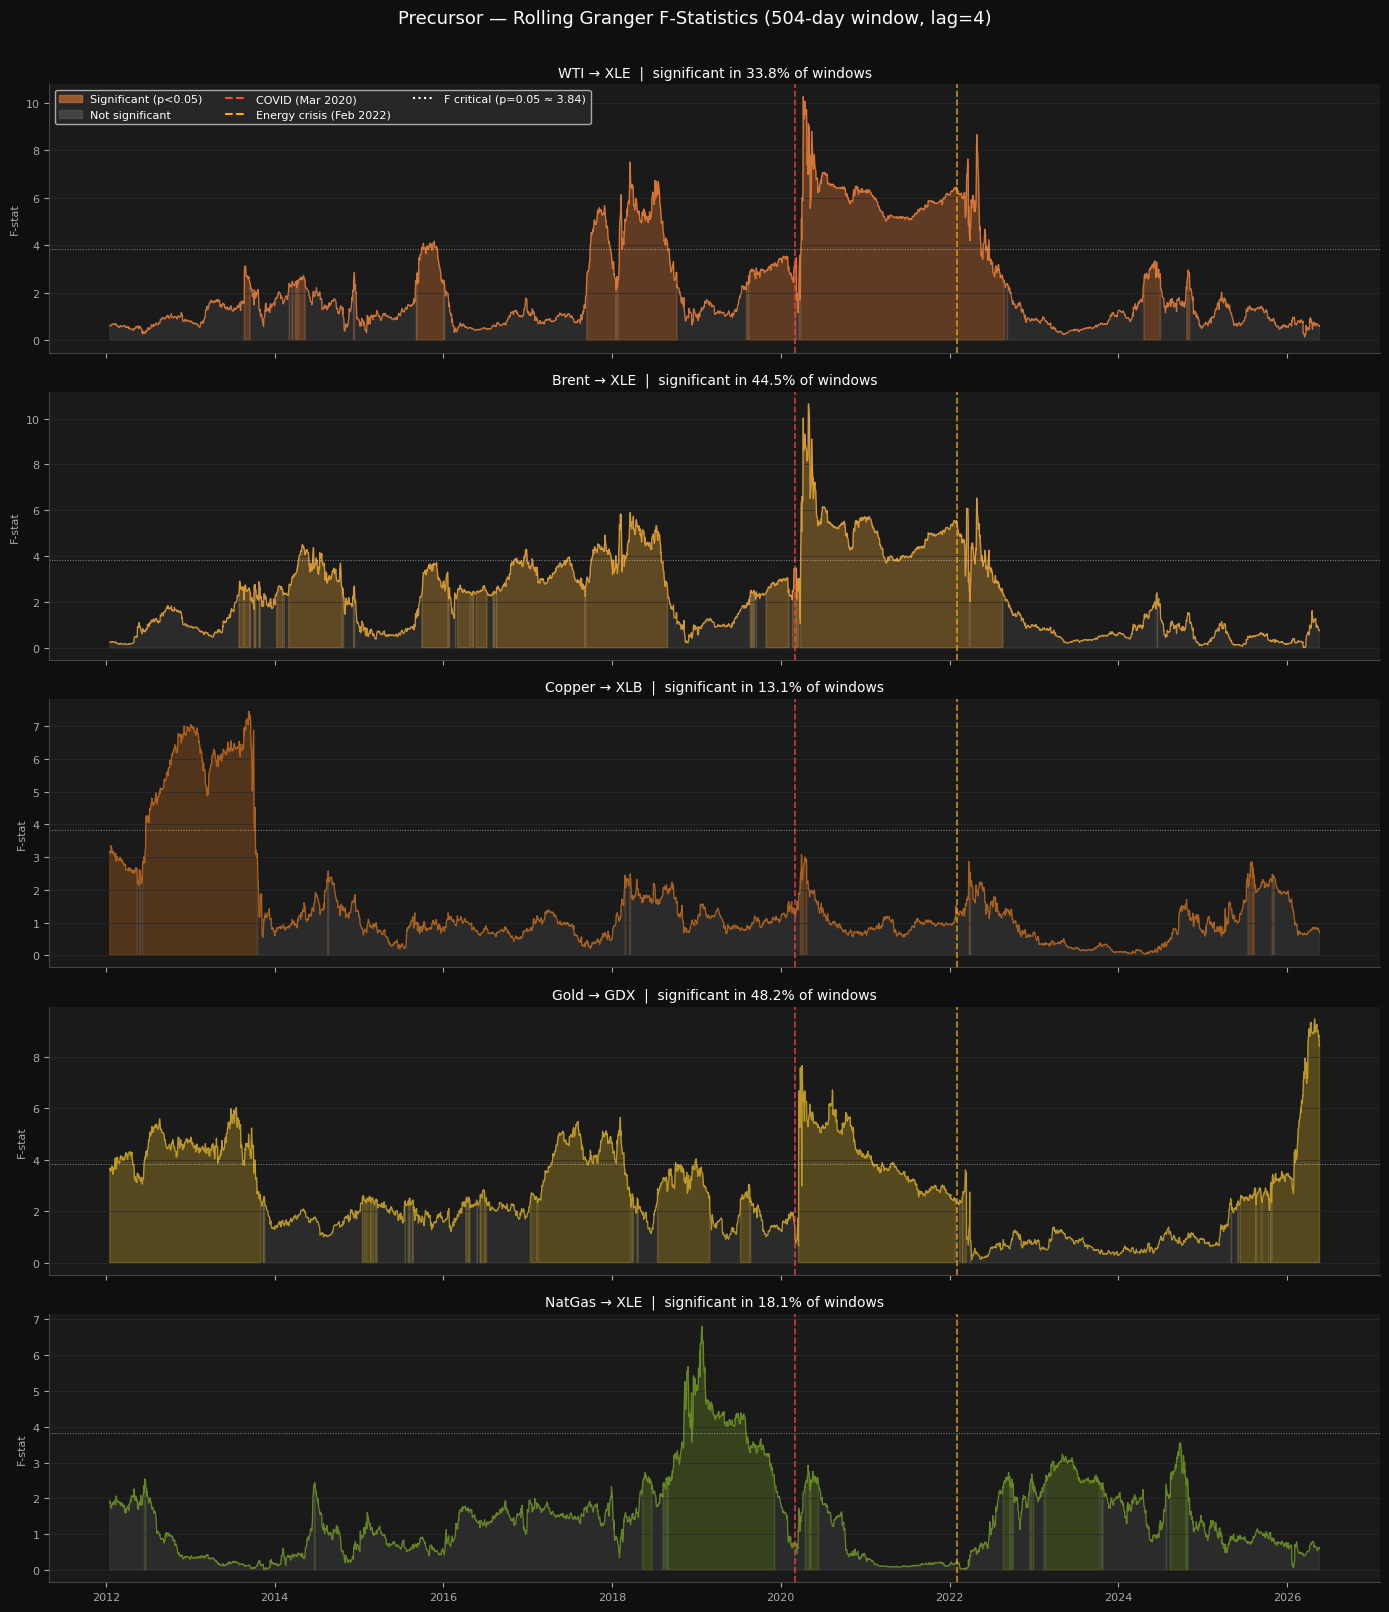

Saved: figures/05b_rolling_granger.png


In [3]:
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(14, 16), facecolor="#0f0f0f", sharex=True)

for i, (comm, eq) in enumerate(PAIRS):
    ax = axes[i]
    ax.set_facecolor("#1a1a1a")

    rr = rolling_results[(comm, eq)]
    f  = rr["f_stat"]
    p  = rr["p_value"]

    # Shade significant regions
    sig_mask = p < 0.05
    ax.fill_between(f.index, 0, f.where(sig_mask),
                    color=COLORS[comm], alpha=0.35, label="p < 0.05")
    ax.fill_between(f.index, 0, f.where(~sig_mask),
                    color="#555555", alpha=0.3, label="p ≥ 0.05")
    ax.plot(f.index, f, color=COLORS[comm], linewidth=0.9, alpha=0.9)

    # Breakpoint lines
    ax.axvline(BREAK_COVID,  color="#ff4444", linewidth=1.2, linestyle="--", alpha=0.8)
    ax.axvline(BREAK_ENERGY, color="#ffaa00", linewidth=1.2, linestyle="--", alpha=0.8)

    # Critical F value at p=0.05 (approximate)
    ax.axhline(3.84, color="white", linewidth=0.7, linestyle=":", alpha=0.5)

    sig_pct = sig_mask.mean()
    ax.set_title(f"{comm} → {eq}  |  significant in {sig_pct:.1%} of windows",
                 color="white", fontsize=10, pad=6)
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["bottom","left"]].set_color("#444444")
    ax.set_ylabel("F-stat", color="#aaaaaa", fontsize=8)
    ax.grid(axis="y", color="#2a2a2a", linewidth=0.5)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Legend
legend_elements = [
    mpatches.Patch(color="#e07b39", alpha=0.6, label="Significant (p<0.05)"),
    mpatches.Patch(color="#555555", alpha=0.6, label="Not significant"),
    plt.Line2D([0],[0], color="#ff4444", linestyle="--", label="COVID (Mar 2020)"),
    plt.Line2D([0],[0], color="#ffaa00", linestyle="--", label="Energy crisis (Feb 2022)"),
    plt.Line2D([0],[0], color="white",   linestyle=":",  label="F critical (p=0.05 ≈ 3.84)"),
]
axes[0].legend(handles=legend_elements, facecolor="#2a2a2a", labelcolor="white",
               fontsize=8, loc="upper left", ncol=3)

fig.suptitle(f"Precursor — Rolling Granger F-Statistics ({ROLLING_WINDOW}-day window, lag={ROLL_LAG})",
             color="white", fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05b_rolling_granger.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/05b_rolling_granger.png")

---
### 4. Structural Break — Chow Test

The Chow test asks: did the regression coefficients in the Granger model change significantly at a known breakpoint?

For each pair, we run OLS on the unrestricted Granger model and test whether the coefficients differ across the two subsamples split at `BREAK_COVID`.

In [4]:
def chow_test(x_series, y_series, breakpoint, lag):
    """
    Chow test for structural break at breakpoint.
    Tests whether OLS coefficients differ across the two subsamples.
    Returns F-statistic and p-value.
    """
    from scipy import stats as scipy_stats

    data = pd.DataFrame({"Y": y_series, "X": x_series}).dropna()

    # Build lagged features
    for k in range(1, lag + 1):
        data[f"Y_lag{k}"] = data["Y"].shift(k)
        data[f"X_lag{k}"] = data["X"].shift(k)
    data = data.dropna()

    feature_cols = [f"Y_lag{k}" for k in range(1, lag+1)] + [f"X_lag{k}" for k in range(1, lag+1)]
    X_full = add_constant(data[feature_cols])
    y_full = data["Y"]

    # Full sample RSS
    rss_full = OLS(y_full, X_full).fit().ssr

    # Subsample RSSs
    pre  = data[data.index <  breakpoint]
    post = data[data.index >= breakpoint]

    if len(pre) < lag * 3 or len(post) < lag * 3:
        return None, None

    rss_pre  = OLS(pre["Y"],  add_constant(pre[feature_cols])).fit().ssr
    rss_post = OLS(post["Y"], add_constant(post[feature_cols])).fit().ssr

    k   = X_full.shape[1]  # number of parameters
    n   = len(data)
    rss_sum = rss_pre + rss_post

    f_stat = ((rss_full - rss_sum) / k) / (rss_sum / (n - 2 * k))
    p_val  = 1 - scipy_stats.f.cdf(f_stat, k, n - 2 * k)

    return round(f_stat, 4), round(p_val, 4)


print("CHOW TEST — STRUCTURAL BREAK AT COVID (2020-03-01)")
print("=" * 62)
print(f"{'Pair':<15} {'F-stat':>10} {'p-value':>10} {'Break?':>10}")
print("-" * 62)

chow_records = []
for comm, eq in PAIRS:
    lag = int(optimal_lags[(comm, eq)][0])
    w   = int(optimal_lags[(comm, eq)][1])
    x   = momentum[w][comm]
    y   = momentum[w][eq]
    f, p = chow_test(x, y, BREAK_COVID, lag)
    if f is not None:
        sig = "YES" if p < 0.05 else "NO"
        print(f"{comm}→{eq:<10} {f:>10.4f} {p:>10.4f} {sig:>10}")
        chow_records.append({"Pair": f"{comm}→{eq}", "Breakpoint": "COVID",
                              "F_stat": f, "P_value": p, "Significant": p < 0.05})

print("\nCHOW TEST — STRUCTURAL BREAK AT ENERGY CRISIS (2022-02-01)")
print("=" * 62)
print(f"{'Pair':<15} {'F-stat':>10} {'p-value':>10} {'Break?':>10}")
print("-" * 62)

for comm, eq in PAIRS:
    lag = int(optimal_lags[(comm, eq)][0])
    w   = int(optimal_lags[(comm, eq)][1])
    x   = momentum[w][comm]
    y   = momentum[w][eq]
    f, p = chow_test(x, y, BREAK_ENERGY, lag)
    if f is not None:
        sig = "YES" if p < 0.05 else "NO"
        print(f"{comm}→{eq:<10} {f:>10.4f} {p:>10.4f} {sig:>10}")
        chow_records.append({"Pair": f"{comm}→{eq}", "Breakpoint": "Energy",
                              "F_stat": f, "P_value": p, "Significant": p < 0.05})

chow_df = pd.DataFrame(chow_records)

CHOW TEST — STRUCTURAL BREAK AT COVID (2020-03-01)
Pair                F-stat    p-value     Break?
--------------------------------------------------------------
WTI→XLE            4.5031     0.0000        YES
Brent→XLE            4.4446     0.0000        YES
Copper→XLB            3.3943     0.0001        YES
Gold→GDX            1.4047     0.1986         NO
NatGas→XLE            1.1987     0.2908         NO

CHOW TEST — STRUCTURAL BREAK AT ENERGY CRISIS (2022-02-01)
Pair                F-stat    p-value     Break?
--------------------------------------------------------------
WTI→XLE            3.5100     0.0002        YES
Brent→XLE            3.0514     0.0012        YES
Copper→XLB            1.8052     0.0477        YES
Gold→GDX            4.0341     0.0002        YES
NatGas→XLE            2.0817     0.0278        YES


---
### 5. Subsample Analysis — Pre vs Post COVID

Split the full sample at 2020-03-01 and re-run the full Granger test on each subsample. This shows whether the causal structure strengthened, weakened, or disappeared after COVID.

In [5]:
def run_granger_simple(x, y, lag):
    data = pd.DataFrame({"Y": y, "X": x}).dropna()
    res  = grangercausalitytests(data[["Y", "X"]], maxlag=lag, verbose=False)
    return res[lag][0]["ssr_ftest"][0], res[lag][0]["ssr_ftest"][1]


print("SUBSAMPLE GRANGER ANALYSIS")
print("=" * 75)
print(f"{'Pair':<15} {'Full F':>8} {'Full p':>8} {'Pre F':>8} {'Pre p':>8} {'Post F':>8} {'Post p':>8}")
print("-" * 75)

subsample_records = []

for comm, eq in PAIRS:
    lag = int(optimal_lags[(comm, eq)][0])
    w   = int(optimal_lags[(comm, eq)][1])
    x   = momentum[w][comm]
    y   = momentum[w][eq]

    # Full sample
    f_full, p_full = run_granger_simple(x, y, lag)

    # Pre-COVID
    x_pre = x[x.index < BREAK_COVID]
    y_pre = y[y.index < BREAK_COVID]
    f_pre, p_pre = run_granger_simple(x_pre, y_pre, lag)

    # Post-COVID
    x_post = x[x.index >= BREAK_COVID]
    y_post = y[y.index >= BREAK_COVID]
    f_post, p_post = run_granger_simple(x_post, y_post, lag)

    print(f"{comm}→{eq:<10} {f_full:>8.2f} {p_full:>8.4f} {f_pre:>8.2f} {p_pre:>8.4f} {f_post:>8.2f} {p_post:>8.4f}")
    subsample_records.append({
        "Pair": f"{comm}→{eq}",
        "Full_F": f_full, "Full_P": p_full,
        "Pre_F" : f_pre,  "Pre_P" : p_pre,
        "Post_F": f_post, "Post_P": p_post,
        "Pre_Sig" : p_pre  < 0.05,
        "Post_Sig": p_post < 0.05,
    })

subsample_df = pd.DataFrame(subsample_records)

SUBSAMPLE GRANGER ANALYSIS
Pair              Full F   Full p    Pre F    Pre p   Post F   Post p
---------------------------------------------------------------------------
WTI→XLE            8.78   0.0000     1.05   0.3783    10.16   0.0000
Brent→XLE            5.89   0.0001     1.31   0.2646     8.07   0.0000
Copper→XLB            2.93   0.0121     1.70   0.1318     2.39   0.0363
Gold→GDX           18.90   0.0000    11.66   0.0000     8.60   0.0000
NatGas→XLE            2.43   0.0457     3.45   0.0081     0.80   0.5257


---
### 6. Visualise Subsample F-Statistics

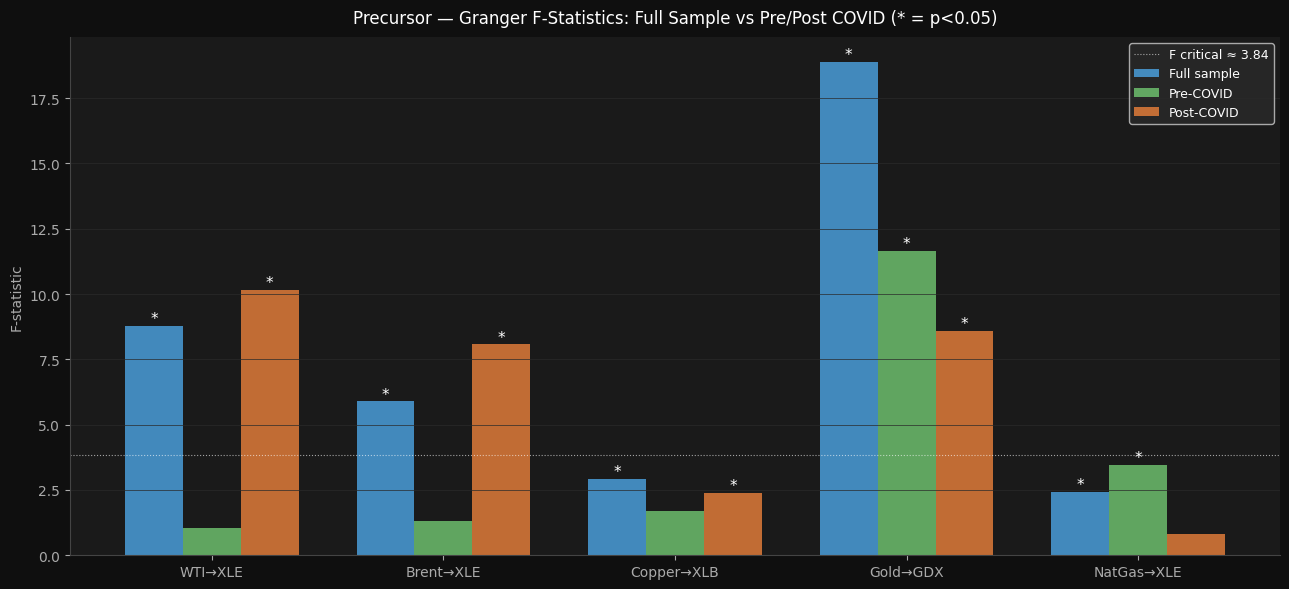

Saved: figures/05b_subsample_fstats.png


In [6]:
pair_labels = [f"{c}→{e}" for c, e in PAIRS]
x_pos = np.arange(len(PAIRS))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6), facecolor="#0f0f0f")
ax.set_facecolor("#1a1a1a")

bars1 = ax.bar(x_pos - width, subsample_df["Full_F"],  width, label="Full sample",  color="#4a9eda", alpha=0.85)
bars2 = ax.bar(x_pos,         subsample_df["Pre_F"],   width, label="Pre-COVID",    color="#6dbf6d", alpha=0.85)
bars3 = ax.bar(x_pos + width, subsample_df["Post_F"],  width, label="Post-COVID",   color="#e07b39", alpha=0.85)

# Significance markers
for i, row in subsample_df.iterrows():
    if row["Full_P"]  < 0.05: ax.text(x_pos[i] - width, row["Full_F"]  + 0.1, "*", ha="center", color="white", fontsize=11)
    if row["Pre_Sig"]:         ax.text(x_pos[i],         row["Pre_F"]   + 0.1, "*", ha="center", color="white", fontsize=11)
    if row["Post_Sig"]:        ax.text(x_pos[i] + width, row["Post_F"]  + 0.1, "*", ha="center", color="white", fontsize=11)

ax.axhline(3.84, color="white", linewidth=0.8, linestyle=":", alpha=0.6, label="F critical ≈ 3.84")
ax.set_xticks(x_pos)
ax.set_xticklabels(pair_labels, color="white", fontsize=10)
ax.set_ylabel("F-statistic", color="#aaaaaa")
ax.tick_params(colors="#aaaaaa")
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("#444444")
ax.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=9)
ax.set_title("Precursor — Granger F-Statistics: Full Sample vs Pre/Post COVID (* = p<0.05)",
             color="white", fontsize=12, pad=10)
ax.grid(axis="y", color="#2a2a2a", linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05b_subsample_fstats.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/05b_subsample_fstats.png")

---
### 7. Save Results

In [7]:
# Save rolling results
for (comm, eq), df in rolling_results.items():
    path = os.path.join(OUT_DIR, f"rolling_granger_{comm.lower()}_{eq.lower()}.csv")
    df.to_csv(path)
    print(f"Saved: {path}")

# Save Chow test results
chow_path = os.path.join(OUT_DIR, "chow_test_results.csv")
chow_df.to_csv(chow_path, index=False)
print(f"Saved: {chow_path}")

# Save subsample results
sub_path = os.path.join(OUT_DIR, "subsample_granger.csv")
subsample_df.to_csv(sub_path, index=False)
print(f"Saved: {sub_path}")

Saved: ..\outputs\rolling_granger_wti_xle.csv
Saved: ..\outputs\rolling_granger_brent_xle.csv
Saved: ..\outputs\rolling_granger_copper_xlb.csv
Saved: ..\outputs\rolling_granger_gold_gdx.csv
Saved: ..\outputs\rolling_granger_natgas_xle.csv
Saved: ..\outputs\chow_test_results.csv
Saved: ..\outputs\subsample_granger.csv


---
### 8. Summary

| Output | Path |
|---|---|
| Rolling Granger results (per pair) | `outputs/rolling_granger_{pair}.csv` |
| Chow test results | `outputs/chow_test_results.csv` |
| Subsample analysis | `outputs/subsample_granger.csv` |
| Rolling F-stat plot | `figures/05b_rolling_granger.png` |
| Subsample bar chart | `figures/05b_subsample_fstats.png` |

**Interpretation guide for the paper:**
- If rolling significance > 60% of windows → report as **structurally persistent**
- If Chow test is significant (p < 0.05) at COVID → report as **regime-dependent**, discuss in robustness section
- If Post-COVID F > Pre-COVID F → the relationship **strengthened** after 2020 (common in energy markets post-supply shock)
- NatGas → XLE expected to be the least stable — use this to justify its marginal classification
